In [ ]:
pip install wget gdown

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=38aff5d04294efc063585f3d5f81e5161bfbe5cd411b9bc79e72e26eeadffd2c
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
import gdown
gdown.download(id="1_MFvRhEi4g28V9xbTCDKA13SeR1K9SgF", output="tbc_dataset.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1_MFvRhEi4g28V9xbTCDKA13SeR1K9SgF
From (redirected): https://drive.google.com/uc?id=1_MFvRhEi4g28V9xbTCDKA13SeR1K9SgF&confirm=t&uuid=b0b44b40-ca3f-49e3-accd-4d159a6b6a4c
To: /content/tbc_dataset.zip
100%|██████████| 121M/121M [00:02<00:00, 51.1MB/s]


'tbc_dataset.zip'

In [ ]:
import zipfile
zip_path = "tbc_dataset.zip"
extract_to ="./"

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Selesai extract ke:", extract_to)
except zipfile.BadZipFile:
    print(f"Error: The file '{zip_path}' is not a valid zip file. Please check if the download was successful and the file is not corrupted.")
except FileNotFoundError:
    print(f"Error: The file '{zip_path}' was not found. Please ensure it has been downloaded.")

Selesai extract ke: ./


## Data Preparation

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier # Added for Random Forest
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from skimage import exposure

In [ ]:
# # Function for lung segmentation
# def lung_segmentation(image_gray):
#     # Apply CLAHE for contrast enhancement
#     clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
#     cl1 = clahe.apply(image_gray)

#     # Apply adaptive thresholding to get a binary image
#     thresh = cv2.adaptiveThreshold(cl1, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
#                                    cv2.THRESH_BINARY_INV, 11, 2)

#     # Morphological operations
#     # Erosion followed by dilation to remove small noise (opening)
#     kernel = np.ones((5,5), np.uint8)
#     opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

#     # Dilation followed by erosion to fill small holes (closing)
#     closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)

#     # Find contours
#     contours, hierarchy = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#     # Create an empty mask
#     lung_mask = np.zeros_like(image_gray, dtype=np.uint8)

#     if contours:
#         # Sort contours by area and get the two largest (assumed to be lungs)
#         # This assumes that the lungs are the two largest connected components
#         contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]

#         # Draw the two largest contours on the mask
#         cv2.drawContours(lung_mask, contours, -1, (255), thickness=cv2.FILLED)

#     # Apply the mask to the original grayscale image
#     segmented_lungs = cv2.bitwise_and(image_gray, image_gray, mask=lung_mask)

#     return segmented_lungs, lung_mask


In [ ]:
# Constants and configuration
IMAGE_SIZE = (64, 64)  # Resize images to 64x64 for consistency
ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)
TEST_SIZE = 0.2
RANDOM_STATE = 42
DATASET_DIR = 'tbc_dataset.zip'

In [ ]:
# Function to load an image
def load_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print('Error: Could not load image.')
        return None, None
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image, gray

In [ ]:
# HOG feature extraction function
def extract_hog_features(image_gray):
    features, hog_image = hog(
        image_gray,
        orientations=ORIENTATIONS,
        pixels_per_cell=PIXELS_PER_CELL,
        cells_per_block=CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        visualize=True,
        feature_vector=True
    )
    return features, hog_image

In [ ]:
# Function to crop the image from nose to mouth region
def crop_half_image(img, bottom=True):
    h = img.shape[0]
    mid = h // 2
    if bottom:
        cropped = img[mid:, :]
    else:
        cropped = img[:mid, :]
    return cropped

In [ ]:
# Load the dataset and extract HOG features
X = []
y = []
hog_img = []

# DATASET_DIR should be '.' as the zip was extracted directly here
DATASET_DIR = '.'

for root, dirs, files in os.walk(DATASET_DIR):
    folder_name = os.path.basename(root)
    if folder_name not in ["Normal", "Tuberculosis"]:
        continue

    print(f"Processing {root}")
    for f in files:
        # Ensure we only process image files, e.g., png, jpg, jpeg
        if not (f.lower().endswith(('.png', '.jpg', '.jpeg'))):
            continue

        image_path = os.path.join(root, f)
        image_rgb, image_gray = load_image(image_path)

        if image_gray is None:
            print(f"Warning: Could not load or process image: {image_path}. Skipping.")
            continue

        # Revert to cropping the bottom half of the image
        img_cropped = crop_half_image(image_gray, bottom=True)

        # Fallback to full image if cropped is invalid or too small
        if img_cropped is None or img_cropped.size == 0 or img_cropped.shape[0] < 4 or img_cropped.shape[1] < 4:
            img_cropped = image_gray
            print(f"Warning: Cropped image for {image_path} is invalid or too small. Using full image as fallback.")

        # Resize the processed region to IMAGE_SIZE
        roi_resized = cv2.resize(img_cropped, IMAGE_SIZE, interpolation=cv2.INTER_AREA)

        hog_feature, hog_maps = extract_hog_features(roi_resized)

        if hog_feature is None:
            print(f"Warning: Could not extract HOG features for {image_path}. Skipping.")
            continue

        hog_img.append(hog_maps)
        X.append(hog_feature)

        # Label the images (0 = Normal, 1 = TB Positive)
        if folder_name == "Normal":
            y.append(0)  # Normal (TB Negative)
        elif folder_name == "Tuberculosis":
            y.append(1)  # TB Positive

X = np.array(X)
y = np.array(y)
print(f"[INFO] Total samples: {X.shape[0]}, Feature dimension: {X.shape[1]}")

Processing ./Tuberculosis
Processing ./Normal
[INFO] Total samples: 800, Feature dimension: 1764


## Data Splitting and Feature Scaling

In [ ]:
# Split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Training and Evaluate

In [ ]:
# Train the SVM model
clf = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
print("[INFO] Training SVM...")
clf.fit(X_train_s, y_train)

[INFO] Training SVM...


SVC(probability=True, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# Evaluate the model
y_pred = clf.predict(X_test_s)
print("\n[RESULT] Classification report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "TB Positive"]))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# Calculate AUC
if hasattr(clf, "predict_proba"):
    y_prob = clf.predict_proba(X_test_s)[:, 1] # Probability of positive class
    auc = roc_auc_score(y_test, y_prob)
    print(f"AUC: {auc:.4f}")
else:
    print("AUC cannot be calculated: Estimator does not have 'predict_proba' method.")


[RESULT] Classification report:
              precision    recall  f1-score   support

      Normal       0.95      0.90      0.92        80
 TB Positive       0.90      0.95      0.93        80

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.92       160
weighted avg       0.93      0.93      0.92       160

Confusion matrix:
[[72  8]
 [ 4 76]]
AUC: 0.9702


In [ ]:
# Save the model and scaler
MODEL_PATH = "svm_tb_model.pkl"
joblib.dump({"model": clf, "scaler": scaler}, MODEL_PATH)
print(f"[INFO] Model saved to: {MODEL_PATH}")

[INFO] Model saved to: svm_tb_model.pkl


## Prediction on New Image

In [ ]:
# Function to predict a single image
def predict_image(image, features, model_path):
    data = joblib.load(model_path)
    model_loaded = data.get("model")
    scaler = data.get("scaler")

    if scaler is not None:
        features = scaler.transform(features)

    pred = model_loaded.predict(features)[0]
    conf = None
    prob = 0
    prob = model_loaded.predict_proba(features)[0] if hasattr(model_loaded, "predict_proba") else None
    conf = float(max(prob))

    label_str = "TB Positive" if pred == 1 else "Normal"
    print(f"Prediction: {label_str}")
    return draw_result(image, conf, label_str)


In [ ]:
# Function to draw the result on the image
def draw_text(image, label, score, pos=(10, 30)):
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6
    font_thickness = 2
    text_color = (255, 255, 255)
    text_color_bg = (0, 0, 255)

    score_text = f'Score: {score:.2f}'
    (w1, h1), _ = cv2.getTextSize(score_text, font, font_scale, font_thickness)
    (w2, h2), _ = cv2.getTextSize(label, font, font_scale, font_thickness)

    box_width = max(w1, w2) + 20
    box_height = h1 + h2 + 25

    x, y = pos
    x = max(0, x)
    y = max(box_height, y)

    cv2.rectangle(image, (x, y - box_height), (x + box_width, y), text_color_bg, -1)
    cv2.putText(image, label, (x + 10, y - h1 - 10), font, font_scale, text_color, font_thickness)
    cv2.putText(image, score_text, (x + 10, y - 10), font, font_scale, text_color, font_thickness)

def draw_result(image_bgr, score, label):
    result_image = image_bgr.copy()
    draw_text(result_image, label, score, pos=(10, 40))
    return result_image


## Testing

Prediction: Normal


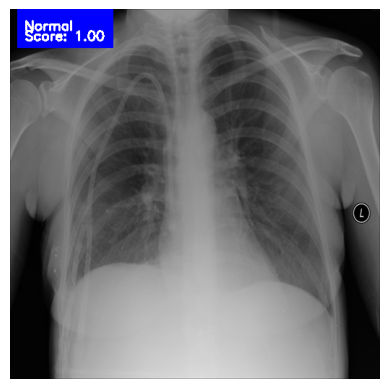

In [ ]:
# Test prediction on a single image
TESTING_IMAGE = "./Normal/Normal-1.png"  # Changed to a valid image path from the extracted dataset
image_rgb, image_gray = load_image(TESTING_IMAGE)

# Check if image_gray was loaded successfully before proceeding
if image_gray is None:
    print(f"Error: Failed to load image from {TESTING_IMAGE}. Please ensure the path is correct and the image exists.")
else:
    # Replicate preprocessing steps from training data pipeline
    img_crop = crop_half_image(image_gray, bottom=True)

    if img_crop is None or img_crop.size == 0 or img_crop.shape[0] < 4 or img_crop.shape[1] < 4:
        img_crop = image_gray  # Fallback to full image if crop is invalid or too small

    # Resize to IMAGE_SIZE before HOG feature extraction
    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)

    hog_feature, hog_maps = extract_hog_features(roi_resized) # Extract HOG from the preprocessed image

    if hog_feature is None:
        print(f"Error: Failed to extract HOG features from {TESTING_IMAGE}.")
    else:
        # Reshape hog_feature for single prediction if it's 1D
        if hog_feature.ndim == 1:
            hog_feature = hog_feature.reshape(1, -1)

        result_image = predict_image(image_rgb, hog_feature, MODEL_PATH)

        # Display the result
        plt.imshow(result_image)
        plt.axis('off') # Hide axes for cleaner display
        plt.show()

Prediction: TB Positive


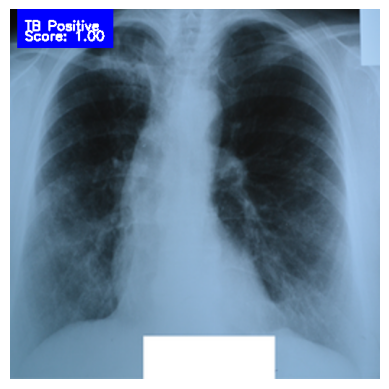

In [ ]:
# Test prediction on a single image
TESTING_IMAGE = "./Tuberculosis/Tuberculosis-1.png"  # Changed to a valid image path from the extracted dataset
image_rgb, image_gray = load_image(TESTING_IMAGE)

# Check if image_gray was loaded successfully before proceeding
if image_gray is None:
    print(f"Error: Failed to load image from {TESTING_IMAGE}. Please ensure the path is correct and the image exists.")
else:
    # Replicate preprocessing steps from training data pipeline
    img_crop = crop_half_image(image_gray, bottom=True)

    if img_crop is None or img_crop.size == 0 or img_crop.shape[0] < 4 or img_crop.shape[1] < 4:
        img_crop = image_gray  # Fallback to full image if crop is invalid or too small

    # Resize to IMAGE_SIZE before HOG feature extraction
    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)

    hog_feature, hog_maps = extract_hog_features(roi_resized) # Extract HOG from the preprocessed image

    if hog_feature is None:
        print(f"Error: Failed to extract HOG features from {TESTING_IMAGE}.")
    else:
        # Reshape hog_feature for single prediction if it's 1D
        if hog_feature.ndim == 1:
            hog_feature = hog_feature.reshape(1, -1)

        result_image = predict_image(image_rgb, hog_feature, MODEL_PATH)

        # Display the result
        plt.imshow(result_image)
        plt.axis('off') # Hide axes for cleaner display
        plt.show()

In [ ]:
# Test prediction on a single image
TESTING_IMAGE = "paru.jpg"  # Changed to a valid image path from the extracted dataset
image_rgb, image_gray = load_image(TESTING_IMAGE)

# Check if image_gray was loaded successfully before proceeding
if image_gray is None:
    print(f"Error: Failed to load image from {TESTING_IMAGE}. Please ensure the path is correct and the image exists.")
else:
    # Replicate preprocessing steps from training data pipeline
    img_crop = crop_half_image(image_gray, bottom=True)

    if img_crop is None or img_crop.size == 0 or img_crop.shape[0] < 4 or img_crop.shape[1] < 4:
        img_crop = image_gray  # Fallback to full image if crop is invalid or too small

    # Resize to IMAGE_SIZE before HOG feature extraction
    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)

    hog_feature, hog_maps = extract_hog_features(roi_resized) # Extract HOG from the preprocessed image

    if hog_feature is None:
        print(f"Error: Failed to extract HOG features from {TESTING_IMAGE}.")
    else:
        # Reshape hog_feature for single prediction if it's 1D
        if hog_feature.ndim == 1:
            hog_feature = hog_feature.reshape(1, -1)

        result_image = predict_image(image_rgb, hog_feature, MODEL_PATH)

        # Display the result
        plt.imshow(result_image)
        plt.axis('off') # Hide axes for cleaner display
        plt.show()

Error: Could not load image.
Error: Failed to load image from paru.jpg. Please ensure the path is correct and the image exists.


# Add Random Forest Model with Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Define the parameter grid for Random Forest tuning
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available CPU cores
    verbose=2, # Display progress messages
    scoring='accuracy' # Optimize for accuracy
)

print("[INFO] Starting Random Forest hyperparameter tuning...")
grid_search.fit(X_train_s, y_train)

# Print best parameters and best score
print("\n[INFO] Best parameters found:", grid_search.best_params_)
print("[INFO] Best cross-validation accuracy:", grid_search.best_score_)

# Get the best estimator
rf_clf_tuned = grid_search.best_estimator_

[INFO] Starting Random Forest hyperparameter tuning...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

[INFO] Best parameters found: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
[INFO] Best cross-validation accuracy: 0.921875


## Evaluate

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# Evaluate the tuned Random Forest model
y_pred_rf_tuned = rf_clf_tuned.predict(X_test_s)
print("\n[RESULT] Tuned Random Forest Classification report:")
print(classification_report(y_test, y_pred_rf_tuned, target_names=["Normal", "TB Positive"]))
print("Confusion matrix (Tuned Random Forest):")
print(confusion_matrix(y_test, y_pred_rf_tuned))

# Calculate AUC for Tuned Random Forest
if hasattr(rf_clf_tuned, "predict_proba"):
    y_prob_rf_tuned = rf_clf_tuned.predict_proba(X_test_s)[:, 1] # Probability of positive class
    auc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)
    print(f"AUC (Tuned Random Forest): {auc_rf_tuned:.4f}")
else:
    print("AUC cannot be calculated for Tuned Random Forest: Estimator does not have 'predict_proba' method.")


[RESULT] Tuned Random Forest Classification report:
              precision    recall  f1-score   support

      Normal       0.88      0.89      0.88        80
 TB Positive       0.89      0.88      0.88        80

    accuracy                           0.88       160
   macro avg       0.88      0.88      0.88       160
weighted avg       0.88      0.88      0.88       160

Confusion matrix (Tuned Random Forest):
[[71  9]
 [10 70]]
AUC (Tuned Random Forest): 0.9464


## Testing with Random Forest

Prediction: TB Positive


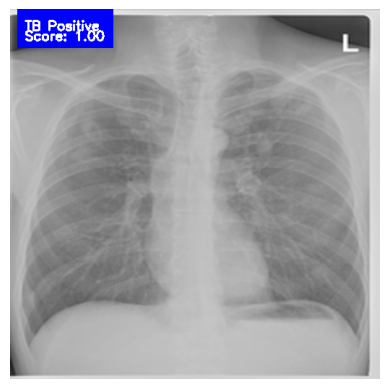

In [ ]:
# Test prediction on a single image
TESTING_IMAGE = "./Tuberculosis/Tuberculosis-60.png"  # Changed to a valid image path from the extracted dataset
image_rgb, image_gray = load_image(TESTING_IMAGE)

# Check if image_gray was loaded successfully before proceeding
if image_gray is None:
    print(f"Error: Failed to load image from {TESTING_IMAGE}. Please ensure the path is correct and the image exists.")
else:
    img_crop = crop_half_image(image_gray, bottom=True)

    if img_crop is None or img_crop.size == 0 or img_crop.shape[0] < 4 or img_crop.shape[1] < 4:
        img_crop = image_gray

    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)

    hog_feature, hog_maps = extract_hog_features(roi_resized)

    if hog_feature is None:
        print(f"Error: Failed to extract HOG features from {TESTING_IMAGE}.")
    else:
        if hog_feature.ndim == 1:
            hog_feature = hog_feature.reshape(1, -1)

        result_image = predict_image(image_rgb, hog_feature, MODEL_PATH)

        # Display the result
        plt.imshow(result_image)
        plt.axis('off') # Hide axes for cleaner display
        plt.show()

Random Forest Prediction: Normal
Confidence: 0.9725


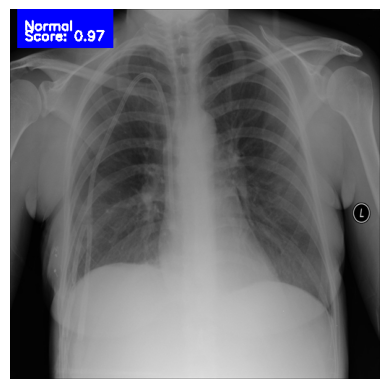

In [ ]:
# Random Forest prediction using the same style as SVM
TESTING_IMAGE = "./Normal/Normal-1.png"  # use same image as SVM if you want

image_rgb, image_gray = load_image(TESTING_IMAGE)

if image_gray is None:
    print(f"Error: Failed to load image from {TESTING_IMAGE}.")
else:

    img_crop = crop_half_image(image_gray, bottom=True)
    if img_crop is None or img_crop.size == 0:
        img_crop = image_gray

    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    hog_feature, hog_maps = extract_hog_features(roi_resized)

    if hog_feature.ndim == 1:
        hog_feature = hog_feature.reshape(1, -1)

    # scale the features
    hog_feature_scaled = scaler.transform(hog_feature)


    rf_pred = rf_clf_tuned.predict(hog_feature_scaled)[0]
    rf_prob = rf_clf_tuned.predict_proba(hog_feature_scaled)[0]
    rf_conf = float(max(rf_prob))

    label_rf = "TB Positive" if rf_pred == 1 else "Normal"
    print("Random Forest Prediction:", label_rf)
    print("Confidence:", rf_conf)


    image_bgr = cv2.imread(TESTING_IMAGE)
    result_rf = draw_result(image_bgr, rf_conf, label_rf)

    # display
    plt.imshow(result_rf)
    plt.axis('off')
